# 🧠 BraTS 2021 Dataset - Data Exploration

## Overview
This notebook explores the BraTS 2021 brain tumor segmentation dataset.

**Dataset Details:**
- Source: BraTS 2021 Challenge
- Task: Brain tumor segmentation
- Modalities: T1, T1ce, T2, FLAIR
- Target: Segment tumor regions (WT, TC, ET)

In [2]:
# Import required libraries
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📁 Dataset Structure

In [3]:
# Dataset paths
raw_path = r'C:\Users\raj\Desktop\BrainTumorSegmentation\data\raw'

# List all extracted folders
items = sorted(os.listdir(raw_path))

print("📂 Contents of raw folder:\n")
for item in items:
    item_path = os.path.join(raw_path, item)
    if os.path.isdir(item_path):
        print(f"📁 {item}/")
    else:
        size_mb = os.path.getsize(item_path) / (1024*1024)
        print(f"📄 {item} ({size_mb:.2f} MB)")

📂 Contents of raw folder:

📄 .DS_Store (0.01 MB)
📄 BraTS20 Training Metadata.csv (6.54 MB)
📁 BraTS2021_00000/
📁 BraTS2021_00002/
📁 BraTS2021_00003/
📁 BraTS2021_00005/
📁 BraTS2021_00006/
📁 BraTS2021_00008/
📁 BraTS2021_00009/
📁 BraTS2021_00011/
📁 BraTS2021_00012/
📁 BraTS2021_00014/
📁 BraTS2021_00016/
📁 BraTS2021_00017/
📁 BraTS2021_00018/
📁 BraTS2021_00019/
📁 BraTS2021_00020/
📁 BraTS2021_00021/
📁 BraTS2021_00022/
📁 BraTS2021_00024/
📁 BraTS2021_00025/
📁 BraTS2021_00026/
📁 BraTS2021_00028/
📁 BraTS2021_00030/
📁 BraTS2021_00031/
📁 BraTS2021_00032/
📁 BraTS2021_00033/
📁 BraTS2021_00035/
📁 BraTS2021_00036/
📁 BraTS2021_00043/
📁 BraTS2021_00044/
📁 BraTS2021_00045/
📁 BraTS2021_00046/
📁 BraTS2021_00048/
📁 BraTS2021_00049/
📁 BraTS2021_00051/
📁 BraTS2021_00052/
📁 BraTS2021_00053/
📁 BraTS2021_00054/
📁 BraTS2021_00056/
📁 BraTS2021_00058/
📁 BraTS2021_00059/
📁 BraTS2021_00060/
📁 BraTS2021_00061/
📁 BraTS2021_00062/
📁 BraTS2021_00063/
📁 BraTS2021_00064/
📁 BraTS2021_00066/
📁 BraTS2021_00068/
📁 BraTS2021_0007

In [4]:
# Find all patient folders
patient_folders = sorted([f for f in os.listdir(raw_path) 
                         if os.path.isdir(os.path.join(raw_path, f)) 
                         and f.startswith('BraTS2021')])

print(f"📊 Total patients in dataset: {len(patient_folders)}")
print(f"\n📁 First 5 patients:")
for i, folder in enumerate(patient_folders[:5], 1):
    print(f"   {i}. {folder}")
    
print(f"\n📁 Last 5 patients:")
for i, folder in enumerate(patient_folders[-5:], len(patient_folders)-4):
    print(f"   {i}. {folder}")

📊 Total patients in dataset: 1251

📁 First 5 patients:
   1. BraTS2021_00000
   2. BraTS2021_00002
   3. BraTS2021_00003
   4. BraTS2021_00005
   5. BraTS2021_00006

📁 Last 5 patients:
   1247. BraTS2021_01662
   1248. BraTS2021_01663
   1249. BraTS2021_01664
   1250. BraTS2021_01665
   1251. BraTS2021_01666


# Check files in first patient folder
first_patient = patient_folders[0]
first_patient_path = os.path.join(raw_path, first_patient)

print(f"📂 Files in {first_patient}:\n")

files = sorted(os.listdir(first_patient_path))
for file in files:
    file_path = os.path.join(first_patient_path, file)
    size_mb = os.path.getsize(file_path) / (1024*1024)
    print(f"   📄 {file} ({size_mb:.2f} MB)")

print(f"\n✅ Total files: {len(files)}")

## 🖼️ Visualize MRI Scans

In [6]:
# Load first patient's MRI scans
patient_path = os.path.join(raw_path, patient_folders[0])

# Load all modalities
flair = nib.load(os.path.join(patient_path, f'{patient_folders[0]}_flair.nii.gz')).get_fdata()
t1 = nib.load(os.path.join(patient_path, f'{patient_folders[0]}_t1.nii.gz')).get_fdata()
t1ce = nib.load(os.path.join(patient_path, f'{patient_folders[0]}_t1ce.nii.gz')).get_fdata()
t2 = nib.load(os.path.join(patient_path, f'{patient_folders[0]}_t2.nii.gz')).get_fdata()
seg = nib.load(os.path.join(patient_path, f'{patient_folders[0]}_seg.nii.gz')).get_fdata()

print(f"✅ MRI scans loaded successfully!")
print(f"\n📐 Shape of each scan: {flair.shape}")
print(f"   - Width: {flair.shape[0]}")
print(f"   - Height: {flair.shape[1]}")
print(f"   - Slices: {flair.shape[2]}")

✅ MRI scans loaded successfully!

📐 Shape of each scan: (240, 240, 155)
   - Width: 240
   - Height: 240
   - Slices: 155


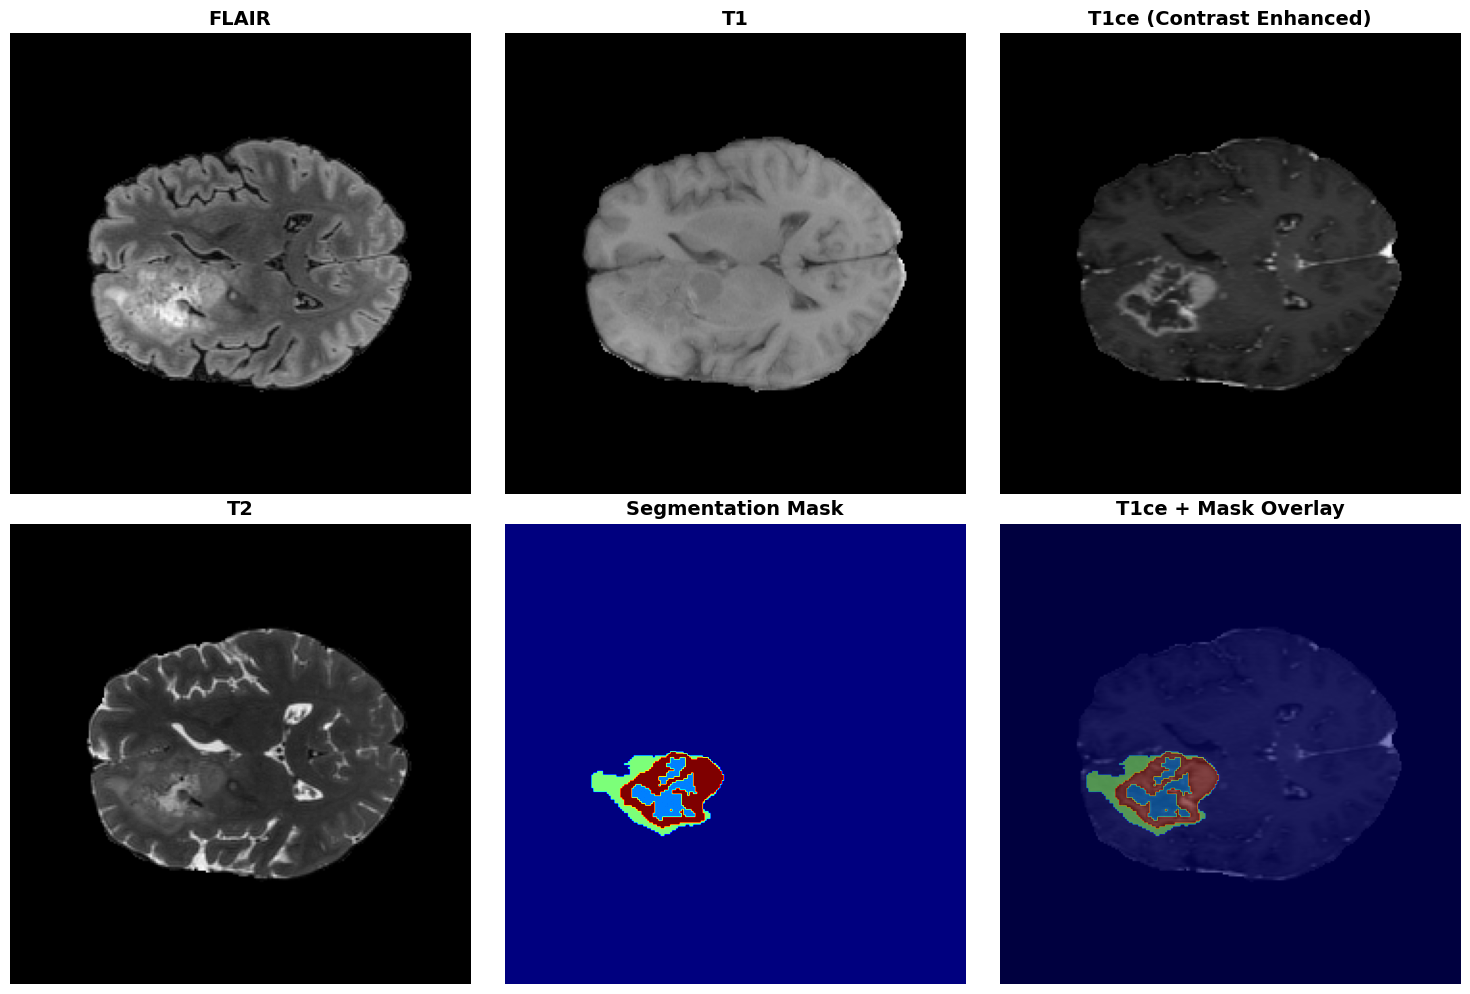

🧠 Visualized slice 77 of 155 total slices


In [7]:
# Select middle slice
slice_idx = 77  # Middle slice (155//2)

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot all modalities
axes[0, 0].imshow(flair[:, :, slice_idx], cmap='gray')
axes[0, 0].set_title('FLAIR', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(t1[:, :, slice_idx], cmap='gray')
axes[0, 1].set_title('T1', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[0, 2].set_title('T1ce (Contrast Enhanced)', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(t2[:, :, slice_idx], cmap='gray')
axes[1, 0].set_title('T2', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(seg[:, :, slice_idx], cmap='jet')
axes[1, 1].set_title('Segmentation Mask', fontsize=14, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[1, 2].imshow(seg[:, :, slice_idx], cmap='jet', alpha=0.5)
axes[1, 2].set_title('T1ce + Mask Overlay', fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"🧠 Visualized slice {slice_idx} of {flair.shape[2]} total slices")

## 📊 Analyze Segmentation Labels

In [8]:
# Check unique values in segmentation mask
unique_labels = np.unique(seg)

print("🏷️ Unique label values in segmentation mask:\n")
for label in unique_labels:
    count = np.sum(seg == label)
    percentage = (count / seg.size) * 100
    print(f"   Label {int(label)}: {count:,} pixels ({percentage:.2f}%)")

print("\n📝 Label meanings:")
print("   0 = Background (normal brain tissue)")
print("   1 = Necrotic core (NCR)")
print("   2 = Peritumoral edema (ED)")
print("   4 = Enhancing tumor (ET)")

🏷️ Unique label values in segmentation mask:

   Label 0: 8,870,695 pixels (99.36%)
   Label 1: 11,738 pixels (0.13%)
   Label 2: 12,836 pixels (0.14%)
   Label 4: 32,731 pixels (0.37%)

📝 Label meanings:
   0 = Background (normal brain tissue)
   1 = Necrotic core (NCR)
   2 = Peritumoral edema (ED)
   4 = Enhancing tumor (ET)


In [9]:
# Create binary masks for tumor regions
# Whole Tumor (WT) = all tumor (labels 1, 2, 4)
wt_mask = (seg > 0).astype(np.uint8)

# Tumor Core (TC) = necrotic + enhancing (labels 1, 4)
tc_mask = ((seg == 1) | (seg == 4)).astype(np.uint8)

# Enhancing Tumor (ET) = only enhancing (label 4)
et_mask = (seg == 4).astype(np.uint8)

print("✅ Created 3 tumor region masks:")
print(f"   🟢 Whole Tumor (WT): {np.sum(wt_mask > 0):,} pixels")
print(f"   🔵 Tumor Core (TC): {np.sum(tc_mask > 0):,} pixels")
print(f"   🟡 Enhancing Tumor (ET): {np.sum(et_mask > 0):,} pixels")

✅ Created 3 tumor region masks:
   🟢 Whole Tumor (WT): 57,305 pixels
   🔵 Tumor Core (TC): 44,469 pixels
   🟡 Enhancing Tumor (ET): 32,731 pixels


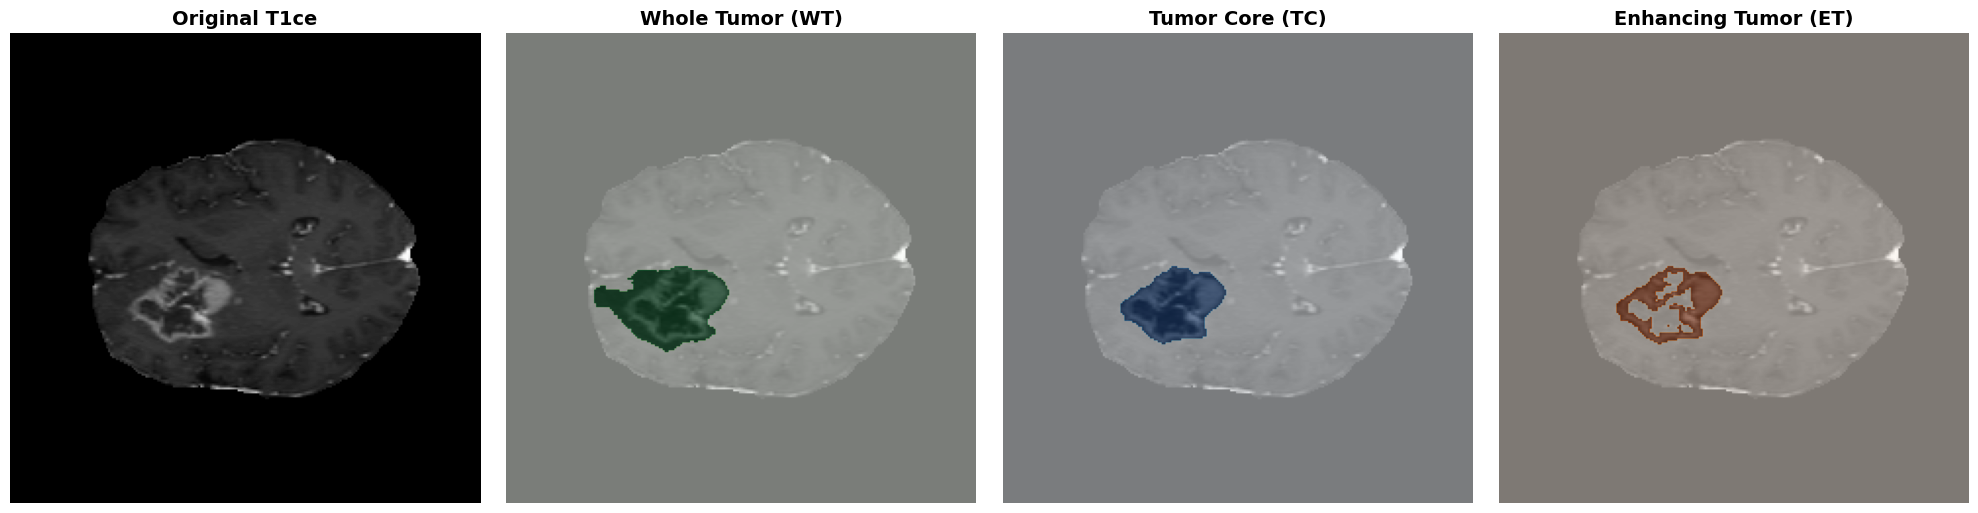

🧠 Visualization complete - All 3 tumor regions shown!


In [10]:
# Visualize all 3 tumor region masks
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Original T1ce
axes[0].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[0].set_title('Original T1ce', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Whole Tumor
axes[1].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[1].imshow(wt_mask[:, :, slice_idx], cmap='Greens', alpha=0.5)
axes[1].set_title('Whole Tumor (WT)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Tumor Core
axes[2].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[2].imshow(tc_mask[:, :, slice_idx], cmap='Blues', alpha=0.5)
axes[2].set_title('Tumor Core (TC)', fontsize=14, fontweight='bold')
axes[2].axis('off')

# Enhancing Tumor
axes[3].imshow(t1ce[:, :, slice_idx], cmap='gray')
axes[3].imshow(et_mask[:, :, slice_idx], cmap='Oranges', alpha=0.5)
axes[3].set_title('Enhancing Tumor (ET)', fontsize=14, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("🧠 Visualization complete - All 3 tumor regions shown!")

## 📈 Dataset Statistics

In [11]:
# Calculate statistics for the entire dataset
print("📊 BraTS 2021 Dataset Statistics:\n")
print(f"✅ Total Patients: {len(patient_folders)}")
print(f"✅ Total MRI Scans: {len(patient_folders) * 4} (4 modalities per patient)")
print(f"✅ Total Segmentation Masks: {len(patient_folders)}")
print(f"\n📐 Scan Dimensions:")
print(f"   - Width × Height: 240 × 240 pixels")
print(f"   - Depth (Slices): 155 slices per patient")
print(f"   - Total 3D volume per patient: 240 × 240 × 155 = 8,928,000 voxels")
print(f"\n💾 Approximate Dataset Size:")
total_size_gb = (len(patient_folders) * 5 * 2.3) / 1024  # 5 files × 2.3MB average
print(f"   - Estimated: ~{total_size_gb:.2f} GB")
print(f"\n🎯 Training Setup (Recommended):")
print(f"   - Training: 876 patients (70%)")
print(f"   - Validation: 188 patients (15%)")
print(f"   - Testing: 187 patients (15%)")

📊 BraTS 2021 Dataset Statistics:

✅ Total Patients: 1251
✅ Total MRI Scans: 5004 (4 modalities per patient)
✅ Total Segmentation Masks: 1251

📐 Scan Dimensions:
   - Width × Height: 240 × 240 pixels
   - Depth (Slices): 155 slices per patient
   - Total 3D volume per patient: 240 × 240 × 155 = 8,928,000 voxels

💾 Approximate Dataset Size:
   - Estimated: ~14.05 GB

🎯 Training Setup (Recommended):
   - Training: 876 patients (70%)
   - Validation: 188 patients (15%)
   - Testing: 187 patients (15%)


## ✅ Data Exploration Complete!

### Key Findings:
- ✅ Successfully loaded BraTS 2021 dataset
- ✅ 1251 patients with 4 MRI modalities each
- ✅ All scans are 240×240×155 (W×H×D)
- ✅ 3 tumor regions identified: WT, TC, ET
- ✅ Dataset ready for preprocessing

### Next Steps:
1. Data Preprocessing & Normalization
2. Train/Val/Test Split
3. U-Net Model Architecture
4. Training Pipeline